<a href="https://colab.research.google.com/github/cikicali369-glitch/DSB-Unit-02/blob/main/Labs/lab-eda-titanic/lab-eda-titanic-student-submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Step 1: Reading the data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load train.csv as a pandas DataFrame
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


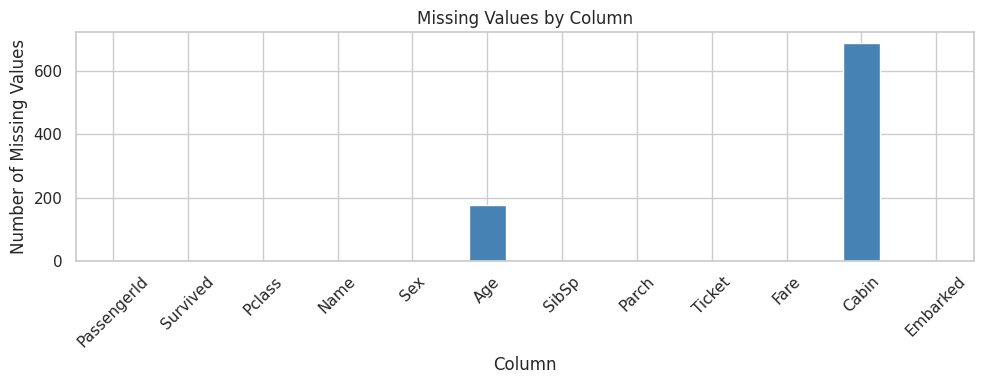

In [16]:
# Create a bar chart showing how many missing values are in each column.
missing_values = df.isna().sum()

missing_values.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Which column has the most NaN values?
# How many cells in that column are empty?
column_name = missing_values.idxmax()
missing_count = missing_values.max()

print(f"The column with the most missing values is {column_name}.")
print(f"It contains {missing_count} missing values.")

The column with the most missing values is Cabin.
It contains 687 missing values.


In [18]:
# Delete all rows where Embarked is empty.
rows_before = len(df)

df = df.dropna(subset=["Embarked"]).copy()

print("Rows removed:", rows_before - len(df))
print("Rows remaining:", len(df))

Rows removed: 2
Rows remaining: 889


In [19]:
# Fill all empty cabins with the required placeholder.
unknown_cabin = r"¯\*(ツ)*/¯"

df["Cabin"] = df["Cabin"].fillna(unknown_cabin)

print("Missing Cabin values remaining:", df["Cabin"].isna().sum())
print("Cabins marked as unknown:", (df["Cabin"] == unknown_cabin).sum())

Missing Cabin values remaining: 0
Cabins marked as unknown: 687


In [20]:
# Create FamilyCount as the sum of SibSp and Parch.
# FamilyCount does not include the passenger themselves.
df["FamilyCount"] = df["SibSp"] + df["Parch"]

display(df[["Name", "SibSp", "Parch", "FamilyCount"]].head())

,Name,SibSp,Parch,FamilyCount
0,"Braund, Mr. Owen Harris",1,0,1
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,1
2,"Heikkinen, Miss. Laina",0,0,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,1
4,"Allen, Mr. William Henry",0,0,0


In [21]:
# Create IsReverend: 1 if the passenger is a preacher, 0 otherwise.
df["IsReverend"] = (
    df["Name"].str.contains(r"\bRev\.", na=False).astype(int)
)

display(df.loc[df["IsReverend"] == 1, ["Name", "IsReverend"]])

,Name,IsReverend
149,"Byles, Rev. Thomas Roussel Davids",1
150,"Bateman, Rev. Robert James",1
249,"Carter, Rev. Ernest Courtenay",1
626,"Kirkland, Rev. Charles Leonard",1
848,"Harper, Rev. John",1
886,"Montvila, Rev. Juozas",1


In [22]:
# Create Embarked_C, Embarked_Q and Embarked_S using pd.get_dummies.
embarked_dummies = pd.get_dummies(df["Embarked"], prefix="Embarked", dtype=int)

df[embarked_dummies.columns] = embarked_dummies

display(df[["Embarked", "Embarked_C", "Embarked_Q", "Embarked_S"]].head())

,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,S,0,0,1
1,C,1,0,0
2,S,0,0,1
3,S,0,0,1
4,S,0,0,1


In [23]:
# Create dummy columns for Sex using pd.get_dummies.
sex_dummies = pd.get_dummies(df["Sex"], prefix="Sex", dtype=int)

df[sex_dummies.columns] = sex_dummies

display(df[["Sex", "Sex_female", "Sex_male"]].head())

,Sex,Sex_female,Sex_male
0,male,0,1
1,female,1,0
2,female,1,0
3,female,1,0
4,male,0,1


In [24]:
# BONUS: Extract the title from each name and create dummy columns.
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

title_dummies = pd.get_dummies(df["Title"], prefix="Title", dtype=int)
df[title_dummies.columns] = title_dummies

display(df[["Name", "Title"]].head())

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [25]:
# What was the survival rate overall?
overall_rate = df["Survived"].mean() * 100

print(f"The overall survival rate was {overall_rate:.2f}%.")

The overall survival rate was 38.25%.


In [26]:
# Which gender fared the worst? What was their survival rate?
gender_rates = df.groupby("Sex")["Survived"].mean() * 100

worst_gender = gender_rates.idxmin()
worst_rate = gender_rates.min()

print("Survival rates by gender (%):")
print(gender_rates.round(2))
print(f"\nThe {worst_gender} group fared the worst, with a survival rate of {worst_rate:.2f}%.")

Survival rates by gender (%):
Sex
female    74.04
male      18.89
Name: Survived, dtype: float64

The male group fared the worst, with a survival rate of 18.89%.


In [27]:
# What was the survival rate for each Pclass?
class_rates = df.groupby("Pclass")["Survived"].mean() * 100

for passenger_class, rate in class_rates.items():
    print(f"Class {passenger_class}: {rate:.2f}%")

Class 1: 62.62%
Class 2: 47.28%
Class 3: 24.24%


In [28]:
# Did any reverends survive? How many?
reverends = df[df["IsReverend"] == 1]
surviving_reverends = reverends["Survived"].sum()

print("Number of reverends:", len(reverends))
print("Number of surviving reverends:", surviving_reverends)

Number of reverends: 6
Number of surviving reverends: 0


In [29]:
# What is the survival rate for cabins marked with the placeholder?
unknown_cabin_passengers = df[df["Cabin"] == unknown_cabin]
unknown_cabin_rate = unknown_cabin_passengers["Survived"].mean() * 100

print(f"The survival rate for passengers with unknown cabins was {unknown_cabin_rate:.2f}%.")

The survival rate for passengers with unknown cabins was 29.99%.


In [30]:
# What is the survival rate for people whose Age is empty?
unknown_age_passengers = df[df["Age"].isna()]
unknown_age_rate = unknown_age_passengers["Survived"].mean() * 100

print(f"The survival rate for passengers with missing ages was {unknown_age_rate:.2f}%.")

The survival rate for passengers with missing ages was 29.38%.


In [31]:
# What is the survival rate for each port of embarkation?
port_rates = df.groupby("Embarked")["Survived"].mean() * 100

port_names = {
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton"
}

for port, rate in port_rates.items():
    print(f"{port_names[port]} ({port}): {rate:.2f}%")

Cherbourg (C): 55.36%
Queenstown (Q): 38.96%
Southampton (S): 33.70%


In [32]:
# What is the survival rate for children (under 12) in each Pclass?
children = df[df["Age"] < 12]

children_summary = children.groupby("Pclass")["Survived"].agg(
    Children="count",
    Survivors="sum",
    SurvivalRate="mean"
)

children_summary["SurvivalRate"] *= 100

print("Survival rates are shown as percentages.")
display(children_summary.round(2))

Survival rates are shown as percentages.


,Children,Survivors,SurvivalRate
Pclass,,,
1,4,3,75.00
2,17,17,100.00
3,47,19,40.43


In [33]:
# Did the captain of the ship survive? Is he on the list?
passengers_with_captain_title = df[
    df["Name"].str.contains(r"\bCapt\.", na=False)
]

display(passengers_with_captain_title[["Name", "Survived"]])

# Search for Titanic's actual captain.
captain_smith = df[
    df["Name"].str.contains(
        r"Smith,.*Edward", case=False, na=False
    )
]

print("Matching rows for Captain Edward Smith:", len(captain_smith))
display(captain_smith[["Name", "Survived"]])

print(
    "The captain of the Titanic was Edward John Smith. "
    "He did not survive and is not included in the standard passenger dataset. "
    "Edward Gifford Crosby was a passenger with the title Capt., "
    "not the captain of the Titanic."
)

,Name,Survived
745,"Crosby, Capt. Edward Gifford",0


Matching rows for Captain Edward Smith: 0


,Name,Survived


The captain of the Titanic was Edward John Smith. He did not survive and is not included in the standard passenger dataset. Edward Gifford Crosby was a passenger with the title Capt., not the captain of the Titanic.


In [34]:
# Of all the people that died, who had the most expensive ticket?
# How much did it cost?
passengers_who_died = df[df["Survived"] == 0]
highest_fare = passengers_who_died["Fare"].max()

highest_fare_passengers = passengers_who_died[
    passengers_who_died["Fare"] == highest_fare
]

print(f"The highest recorded fare among passengers who died was £{highest_fare:.2f}.")
display(highest_fare_passengers[["Name", "Ticket", "Fare"]])

print("A recorded fare may represent a shared ticket rather than an individual price.")

The highest recorded fare among passengers who died was £263.00.


,Name,Ticket,Fare
27,"Fortune, Mr. Charles Alexander",19950,263.0
438,"Fortune, Mr. Mark",19950,263.0


A recorded fare may represent a shared ticket rather than an individual price.


In [35]:
# Does having family on the boat help or hurt your chances of survival?
family_summary = df.groupby("FamilyCount")["Survived"].agg(
    Passengers="count",
    Survivors="sum",
    SurvivalRate="mean"
)

family_summary["SurvivalRate"] *= 100

print("Survival rates are shown as percentages.")
display(family_summary.round(2))

print(
    "In this dataset, passengers with 1–3 family members aboard had higher "
    "survival rates than passengers travelling alone or with 4 or more "
    "family members. This is an association and does not prove causation."
)

Survival rates are shown as percentages.


,Passengers,Survivors,SurvivalRate
FamilyCount,,,
0,535,161,30.09
1,161,89,55.28
2,102,59,57.84
3,29,21,72.41
4,15,3,20.00
5,22,3,13.64
6,12,4,33.33
7,6,0,0.00
10,7,0,0.00


In this dataset, passengers with 1–3 family members aboard had higher survival rates than passengers travelling alone or with 4 or more family members. This is an association and does not prove causation.


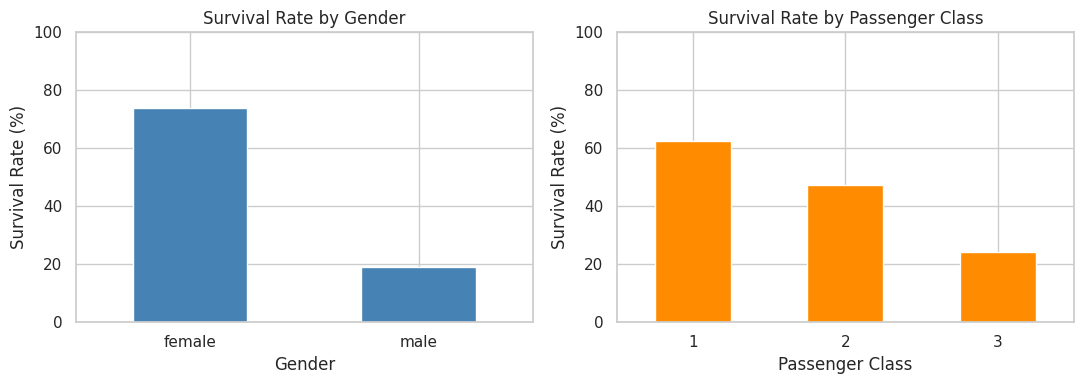

In [36]:
# Plot survival rates by gender and passenger class.
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

gender_rates.plot(kind="bar", ax=axes[0], color="steelblue", rot=0)
axes[0].set_title("Survival Rate by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_ylim(0, 100)

class_rates.plot(kind="bar", ax=axes[1], color="darkorange", rot=0)
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

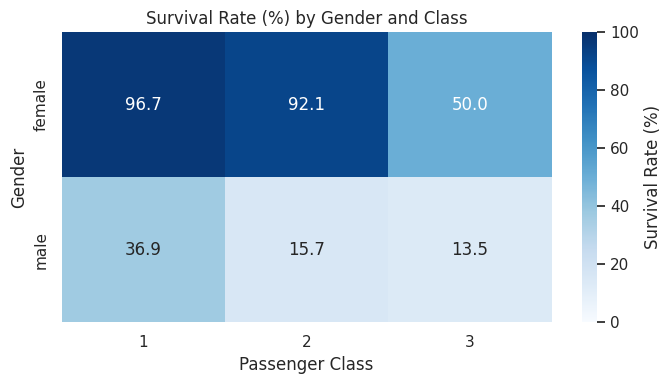

In [37]:
# Compare survival rates by both gender and passenger class.
gender_class_rates = df.pivot_table(
    index="Sex",
    columns="Pclass",
    values="Survived",
    aggfunc="mean"
) * 100

plt.figure(figsize=(7, 4))
sns.heatmap(
    gender_class_rates,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Survival Rate (%)"}
)

plt.title("Survival Rate (%) by Gender and Class")
plt.xlabel("Passenger Class")
plt.ylabel("Gender")
plt.tight_layout()
plt.show()

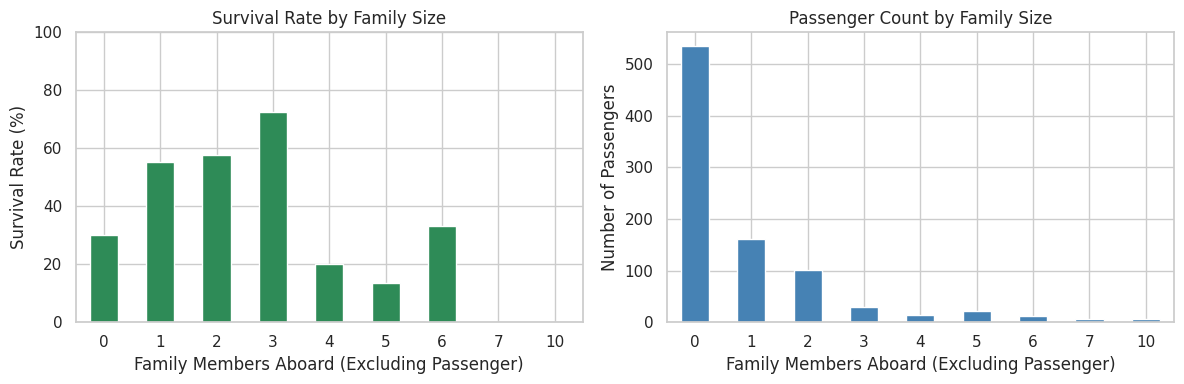

In [38]:
# Compare survival rates and passenger counts by family size.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

family_summary["SurvivalRate"].plot(
    kind="bar", ax=axes[0], color="seagreen", rot=0
)
axes[0].set_title("Survival Rate by Family Size")
axes[0].set_xlabel("Family Members Aboard (Excluding Passenger)")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_ylim(0, 100)

family_summary["Passengers"].plot(
    kind="bar", ax=axes[1], color="steelblue", rot=0
)
axes[1].set_title("Passenger Count by Family Size")
axes[1].set_xlabel("Family Members Aboard (Excluding Passenger)")
axes[1].set_ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

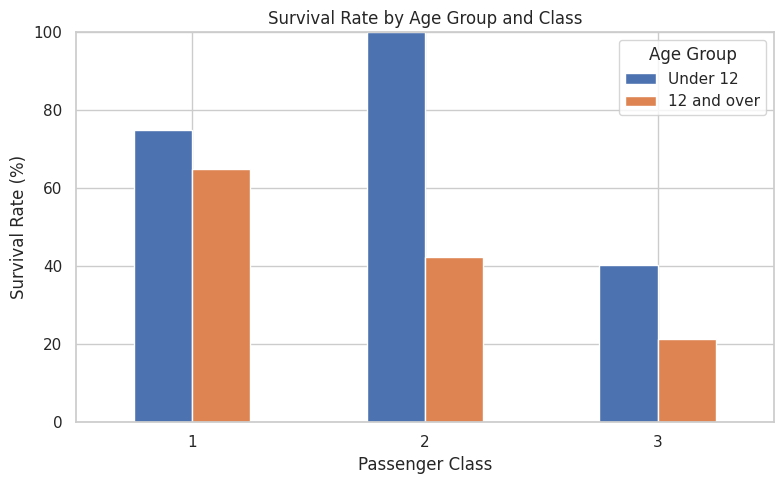

In [39]:
# Compare children under 12 with passengers aged 12 and over by class.
known_age = df.dropna(subset=["Age"]).copy()

known_age["AgeGroup"] = "12 and over"
known_age.loc[known_age["Age"] < 12, "AgeGroup"] = "Under 12"

age_class_rates = known_age.pivot_table(
    index="Pclass",
    columns="AgeGroup",
    values="Survived",
    aggfunc="mean"
) * 100

age_class_rates = age_class_rates[["Under 12", "12 and over"]]

age_class_rates.plot(kind="bar", figsize=(8, 5), rot=0)
plt.title("Survival Rate by Age Group and Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()